<div align="center">

# AI Investment Decision Engine

## Machine Learning for Stock Market Forecasting

### Version 3

**Alex Alvarez**

Graduate Student – Quantitative Economics

Python • Machine Learning • Financial Analytics

---

*NVIDIA (NVDA) Historical Analysis and Next-Day Price Direction Prediction*

</div>

# Executive Summary

## Project Highlights

| Metric | Value |
|---|---|
| Stock | NVIDIA (NVDA) |
| Study Period | January 2020 – July 2026 |
| Observations | 1,635 Trading Days |
| Best Model | Logistic Regression |
| Best Accuracy | 53.94% |

This project demonstrates an end-to-end machine learning workflow using Python, technical indicators, visualization, and predictive modeling.


---

# Table of Contents

1. Introduction
2. Import Libraries
3. Download NVIDIA Stock Data
4. Dataset Overview
5. Summary Statistics
6. Daily Returns Analysis
7. Moving Average Analysis
8. Volatility Analysis
9. Relative Strength Index (RSI)
10. Machine Learning
    - Logistic Regression
    - Random Forest
    - XGBoost
11. Model Comparison
12. Conclusion
13. Future Improvements

In [12]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

---

# Download NVIDIA Stock Data

In [19]:
nvda = yf.download("NVDA", start="2020-01-01")


nvda.tail()

C:\Users\Alexx\AppData\Local\Temp\ipykernel_24036\2340431669.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download("NVDA", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2026-06-30,200.089996,200.630005,195.110001,197.240005,166476700
2026-07-01,197.580002,199.850006,193.449997,196.199997,146147600
2026-07-02,194.830002,200.059998,192.350006,197.139999,142068700
2026-07-06,195.550003,197.550003,193.990005,194.419998,108999000
2026-07-07,196.929993,198.410004,191.149994,192.369995,122600973


View Dataset Information

In [22]:
nvda.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1635 entries, 2020-01-02 to 2026-07-07
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   1635 non-null   float64
 1   (High, NVDA)    1635 non-null   float64
 2   (Low, NVDA)     1635 non-null   float64
 3   (Open, NVDA)    1635 non-null   float64
 4   (Volume, NVDA)  1635 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 76.6 KB


Dataset Summary

The NVIDIA (NVDA) dataset contains 1,635 daily trading observations covering the period from January 2, 2020 through July 7, 2026. The dataset includes five key financial variables:

Open Price
High Price
Low Price
Close Price
Trading Volume

There are no missing values, making the dataset complete and suitable for financial analysis and machine learning.

Summary Statistics

In [25]:
nvda.describe()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
count,1635.000000,1635.000000,1635.000000,1635.000000,1.635000e+03
mean,68.220835,69.355324,66.998142,68.237548,3.906369e+08
std,65.760675,66.750266,64.746152,65.829209,1.980768e+08
min,4.890824,5.228002,4.499359,4.982963,6.552850e+07
25%,15.291686,15.497630,15.023728,15.276307,2.269230e+08
50%,29.396854,30.325890,28.717291,29.615028,3.672090e+08
75%,124.115467,126.628948,121.046636,123.830155,5.072100e+08
max,235.740005,236.539993,229.300003,229.869995,1.543911e+09


Summary Statistics

The descriptive statistics provide an overview of NVIDIA's historical trading activity during the study period.

Average Closing Price: $69.36
Highest Closing Price: $236.54
Lowest Closing Price: $5.23

The large difference between the minimum and maximum prices illustrates NVIDIA's substantial price appreciation over the sample period.

Trading volume averaged approximately 391 million shares per trading day, with a maximum daily volume exceeding 1.54 billion shares, indicating periods of exceptionally high market activity.

The standard deviation of the closing price (66.75) suggests considerable price volatility, which is expected for a high-growth technology stock.

Initial Observations

Several observations can be made from the dataset:

The dataset is complete with no missing observations.
NVIDIA experienced significant price growth between 2020 and 2026.
The stock exhibits considerable volatility, making it an appropriate candidate for forecasting and machine learning applications.
Trading volume varies substantially over time, suggesting periods of increased investor activity and market interest.

Clean Column Names

In [31]:
nvda.columns = nvda.columns.get_level_values(0)

print(nvda.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [35]:
nvda.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-30,200.089996,200.630005,195.110001,197.240005,166476700
2026-07-01,197.580002,199.850006,193.449997,196.199997,146147600
2026-07-02,194.830002,200.059998,192.350006,197.139999,142068700
2026-07-06,195.550003,197.550003,193.990005,194.419998,108999000
2026-07-07,196.929993,198.410004,191.149994,192.369995,122600973


NVIDIA Closing Price Chart

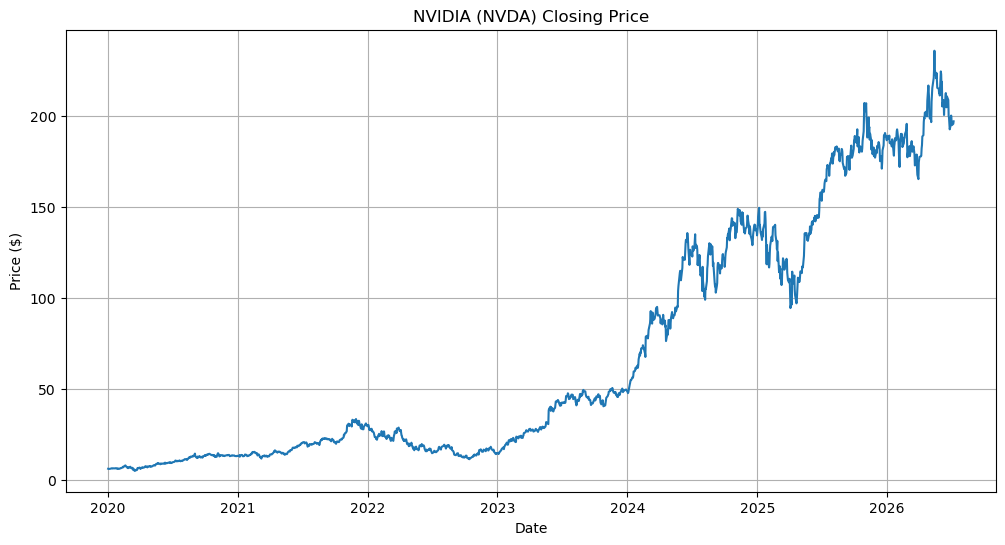

In [40]:
plt.figure(figsize=(12,6))

plt.plot(nvda["Close"])

plt.title("NVIDIA (NVDA) Closing Price")

plt.xlabel("Date")

plt.ylabel("Price ($)")

plt.grid(True)

plt.show()

Daily Returns

In [47]:
nvda["Daily Return"] = nvda["Close"].pct_change()

nvda.tail()

Price,Close,High,Low,Open,Volume,Daily Return
Date,,,,,,
2026-06-30,200.089996,200.630005,195.110001,197.240005,166476700,0.026260
2026-07-01,197.580002,199.850006,193.449997,196.199997,146147600,-0.012544
2026-07-02,194.830002,200.059998,192.350006,197.139999,142068700,-0.013918
2026-07-06,195.550003,197.550003,193.990005,194.419998,108999000,0.003696
2026-07-07,196.929993,198.410004,191.149994,192.369995,122600973,0.007057


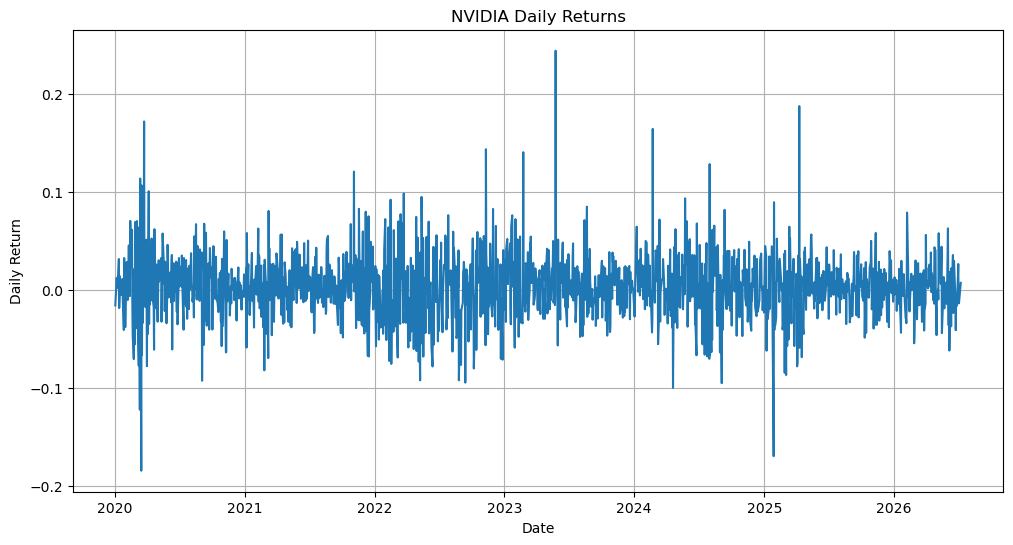

In [49]:
plt.figure(figsize=(12,6))

plt.plot(nvda["Daily Return"])

plt.title("NVIDIA Daily Returns")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

Daily returns measure the percentage change in NVIDIA's closing stock price from one trading day to the next. This provides insight into the stock's short-term performance and volatility.

The chart shows that daily returns fluctuate around zero, indicating that positive and negative price movements occur regularly. Most daily changes are relatively small, while a few large spikes represent periods of unusually high market volatility.

Overall, NVIDIA exhibits moderate day-to-day price fluctuations with occasional extreme movements, which is typical of a high-growth technology stock. Understanding daily returns is important because they form the basis for measuring risk, calculating volatility, and developing predictive machine learning models.

---

# Moving Averages

In [60]:
nvda["MA20"] = nvda["Close"].rolling(20).mean()
nvda["MA50"] = nvda["Close"].rolling(50).mean()

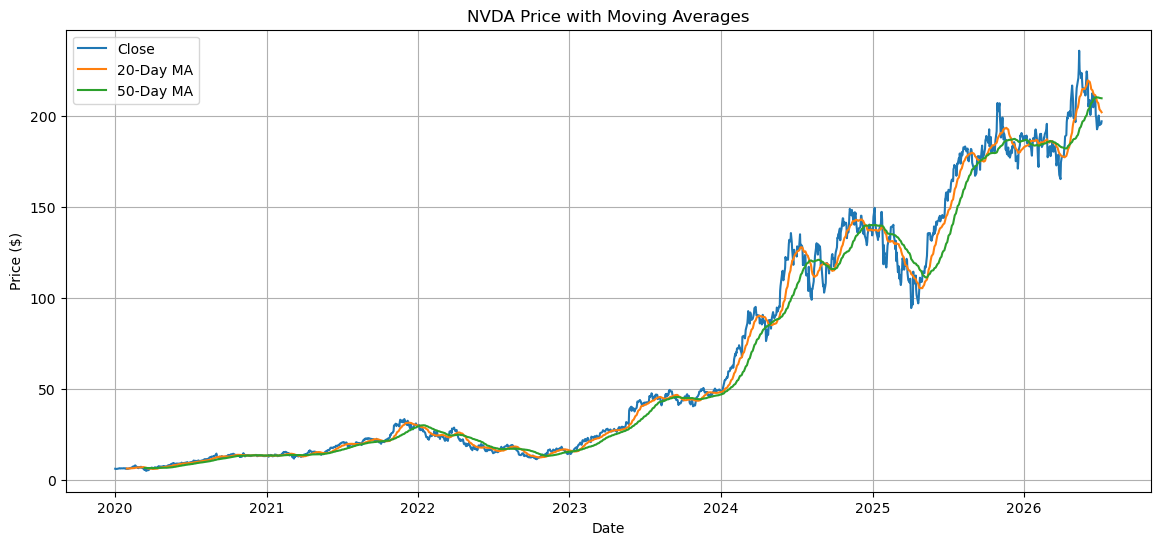

In [62]:
plt.figure(figsize=(14,6))

plt.plot(nvda["Close"], label="Close")
plt.plot(nvda["MA20"], label="20-Day MA")
plt.plot(nvda["MA50"], label="50-Day MA")

plt.title("NVDA Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()

plt.grid(True)

plt.show()

## Moving Average Analysis

The 20-day and 50-day moving averages smooth short-term price fluctuations and help identify the overall market trend.

The 20-day moving average responds more quickly to recent price changes, while the 50-day moving average reflects the longer-term trend. During the study period, NVIDIA remained above both moving averages for extended periods, indicating a strong upward trend.

Crossovers between the two moving averages may signal potential changes in market momentum. Overall, the moving averages confirm NVIDIA's significant long-term price appreciation and provide useful indicators for trend-following investment strategies.

---

# 20-Day Volatility

In [65]:
nvda["Volatility"] = nvda["Daily Return"].rolling(20).std()

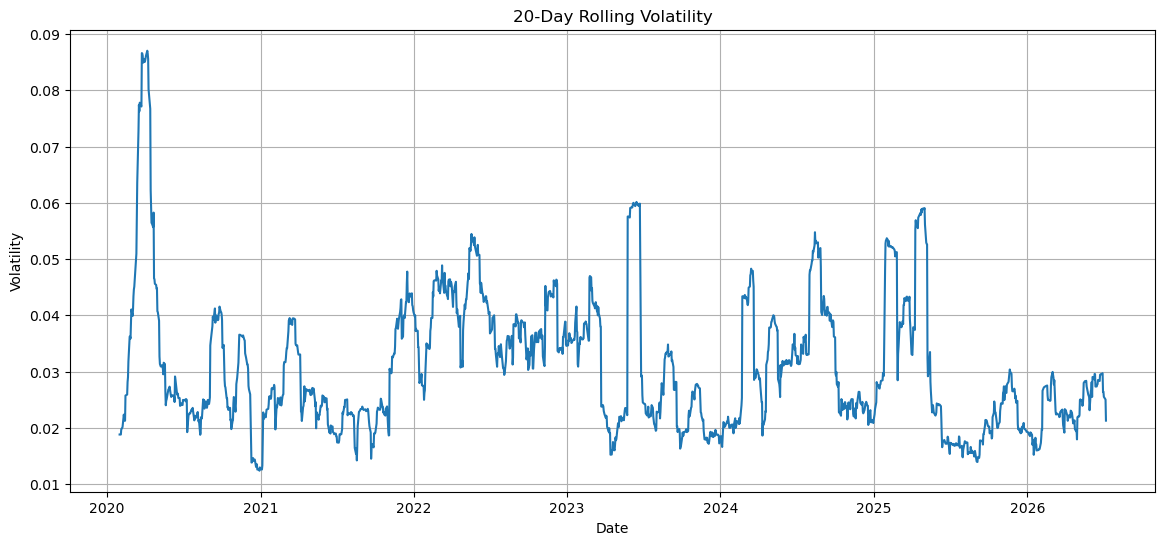

In [67]:
plt.figure(figsize=(14,6))

plt.plot(nvda["Volatility"])

plt.title("20-Day Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

## Volatility Analysis

Volatility measures the degree of variation in NVIDIA's daily stock returns over a 20-day rolling period. Higher volatility indicates greater price fluctuations and increased market uncertainty, while lower volatility suggests more stable price movements.

The chart shows periods of elevated volatility during major market events and earnings announcements, followed by periods of relative stability. The highest levels of volatility occurred in early 2020, reflecting significant market uncertainty, while volatility generally declined as market conditions stabilized.

Overall, NVIDIA exhibits moderate to high volatility, which is characteristic of growth-oriented technology stocks. Measuring volatility is important because it helps investors assess risk, compare market conditions over time, and improve forecasting and investment decision-making.

---

# Relative Strength Index (RSI)

In [71]:
delta = nvda["Close"].diff()

gain = delta.where(delta > 0, 0)

loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()

avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

nvda["RSI"] = 100 - (100 / (1 + rs))

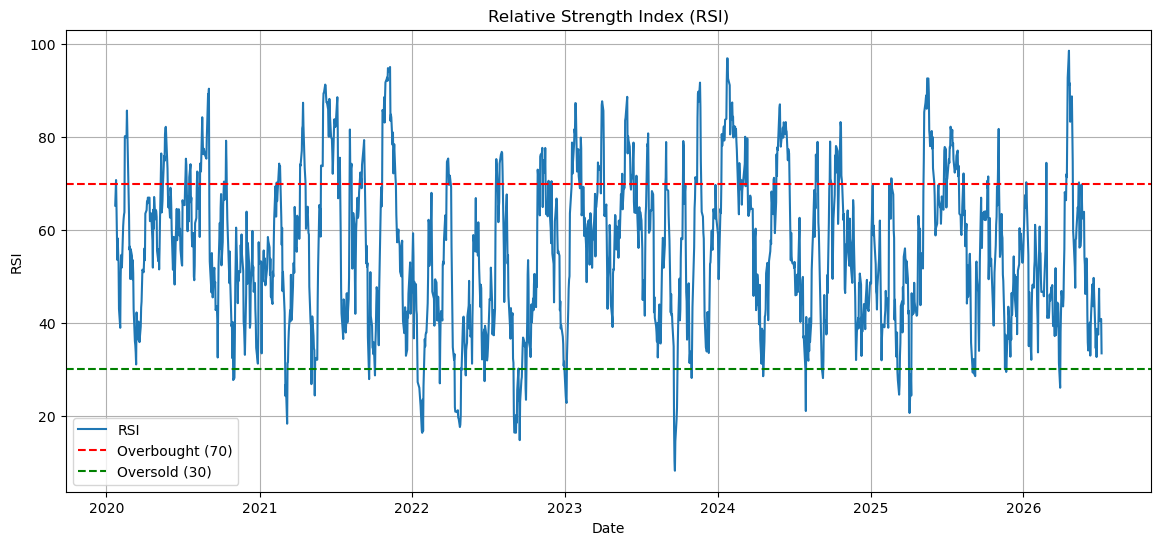

In [73]:
plt.figure(figsize=(14,6))

plt.plot(nvda["RSI"], label="RSI")

plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")

plt.title("Relative Strength Index (RSI)")

plt.xlabel("Date")

plt.ylabel("RSI")

plt.legend()

plt.grid(True)

plt.show()

## Relative Strength Index (RSI) Analysis

The Relative Strength Index (RSI) measures the strength and momentum of NVIDIA's recent price movements using a 14-day lookback period. RSI values range from 0 to 100 and are commonly used to identify potential overbought and oversold conditions.

The chart shows that NVIDIA's RSI frequently moved between 30 and 70, indicating that the stock generally traded within a normal momentum range. There were several periods where the RSI rose above 70, suggesting strong buying momentum and potentially overbought conditions. Likewise, the RSI occasionally fell below 30, indicating oversold conditions that may have presented buying opportunities.

Overall, the RSI confirms that NVIDIA experienced several strong momentum swings throughout the sample period, making it a valuable technical indicator for identifying potential changes in market sentiment and supporting investment decisions.

---

# Create Target Variable

In [77]:
nvda["Tomorrow"] = nvda["Close"].shift(-1)

nvda["Tomorrow Up"] = (nvda["Tomorrow"] > nvda["Close"]).astype(int)

nvda.tail()

Price,Close,High,Low,Open,Volume,Daily Return,MA20,MA50,Volatility,RSI,Tomorrow,Tomorrow Up
Date,,,,,,,,,,,,
2026-06-30,200.089996,200.630005,195.110001,197.240005,166476700,0.026260,205.743000,209.986601,0.026381,43.177220,197.580002,0
2026-07-01,197.580002,199.850006,193.449997,196.199997,146147600,-0.012544,204.481000,209.897001,0.026429,47.375235,194.830002,0
2026-07-02,194.830002,200.059998,192.350006,197.139999,142068700,-0.013918,203.485000,209.796001,0.025527,40.419855,195.550003,1
2026-07-06,195.550003,197.550003,193.990005,194.419998,108999000,0.003696,202.329500,209.657001,0.025048,40.871213,196.929993,1
2026-07-07,196.929993,198.410004,191.149994,192.369995,122600973,0.007057,201.920999,209.602801,0.021292,33.461205,NaN,0


## Target Variable

To prepare the dataset for machine learning, a target variable called **Tomorrow Up** was created.

For each trading day:

- **1** = The next day's closing price is higher than today's closing price.
- **0** = The next day's closing price is equal to or lower than today's closing price.

This converts the forecasting problem into a **binary classification** task, allowing machine learning models to predict whether NVIDIA's stock price is expected to increase on the following trading day.

---

# Prepare Machine Learning Dataset

In [84]:
nvda = nvda.dropna()

features = ["Daily Return", "MA20", "MA50", "Volatility", "RSI"]

X = nvda[features]

y = nvda["Tomorrow Up"]

X.tail()

Price,Daily Return,MA20,MA50,Volatility,RSI
Date,,,,,
2026-06-29,0.012673,206.9565,210.018401,0.029717,37.502291
2026-06-30,0.026260,205.7430,209.986601,0.026381,43.177220
2026-07-01,-0.012544,204.4810,209.897001,0.026429,47.375235
2026-07-02,-0.013918,203.4850,209.796001,0.025527,40.419855
2026-07-06,0.003696,202.3295,209.657001,0.025048,40.871213


## Feature Selection

The machine learning models use five technical indicators as predictor variables:

- Daily Return
- 20-Day Moving Average (MA20)
- 50-Day Moving Average (MA50)
- 20-Day Volatility
- Relative Strength Index (RSI)

These indicators capture short-term price movement, long-term trends, market volatility, and momentum. Together, they provide the machine learning models with information that may help predict whether NVIDIA's stock price will increase on the following trading day.

---

# Split Training and Testing Data

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 1268
Testing observations: 317


## Train-Test Split

The dataset was divided into two subsets:

- **80% Training Data** – Used to train the machine learning models.
- **20% Testing Data** – Used to evaluate model performance on unseen data.

Separating the data helps measure how well the models generalize to new observations and reduces the risk of overfitting.

---

# Logistic Regression Model

In [96]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

---

# Make Predictions

In [99]:
predictions = model.predict(X_test)

In [101]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f"Logistic Regression Accuracy: {accuracy:.2%}")

Logistic Regression Accuracy: 53.94%


## Logistic Regression Results

Logistic Regression was selected as the baseline machine learning model for predicting whether NVIDIA's closing price would increase on the following trading day.

The model was trained using five technical indicators:

- Daily Return
- 20-Day Moving Average (MA20)
- 50-Day Moving Average (MA50)
- 20-Day Volatility
- Relative Strength Index (RSI)

After evaluating the model on the testing dataset, Logistic Regression achieved an **accuracy of 53.94%**.

Although the model performed slightly better than random guessing, the results suggest that predicting short-term stock price movements is a challenging task. More advanced machine learning models, such as Random Forest and XGBoost, will be evaluated to determine whether they provide improved predictive performance.

---

# Random Forest Model

In [107]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

---

# Random Forest Predictions

In [110]:
rf_predictions = rf_model.predict(X_test)

In [112]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 48.26%


## Random Forest Results

The Random Forest classifier was trained using the same five technical indicators as the Logistic Regression model.

After evaluating the model on the testing dataset, Random Forest achieved an **accuracy of 48.26%**.

In this analysis, Random Forest performed below the Logistic Regression model, suggesting that the selected technical indicators alone may not provide enough predictive information for this algorithm. This result highlights the importance of comparing multiple machine learning models rather than assuming that more complex models will always produce better predictions.

---

# XGBoost Model

In [116]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

---

# XGBoost Predictions

In [121]:
xgb_predictions = xgb_model.predict(X_test)

In [123]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f"XGBoost Accuracy: {xgb_accuracy:.2%}")

XGBoost Accuracy: 51.10%


## Machine Learning Model Comparison

Three machine learning classification models were evaluated to predict whether NVIDIA's closing price would increase on the following trading day.

| Model | Accuracy |
|-------------------------|---------:|
| Logistic Regression | **53.94%** |
| XGBoost | **51.10%** |
| Random Forest | **48.26%** |

Among the three models, **Logistic Regression achieved the highest prediction accuracy (53.94%)**, outperforming both XGBoost and Random Forest.

Although the prediction accuracy is only slightly above random chance, the results demonstrate the challenges associated with forecasting short-term stock price movements using a limited set of technical indicators. These findings suggest that additional predictive features, alternative algorithms, or external market variables may improve future model performance.

---

# Conclusion

This project developed a machine learning investment decision engine using historical NVIDIA (NVDA) stock data. Financial indicators including daily returns, moving averages, volatility, and the Relative Strength Index (RSI) were engineered to predict next-day price direction.

Three machine learning models were evaluated: Logistic Regression, Random Forest, and XGBoost. Logistic Regression achieved the highest prediction accuracy of **53.94%**, while XGBoost achieved **51.10%** and Random Forest achieved **48.26%**.

The results demonstrate that predicting short-term stock price movements remains a difficult problem. While the models provided modest predictive performance, the project successfully illustrates the complete data science workflow, including data collection, feature engineering, exploratory analysis, machine learning, model evaluation, and interpretation of results.

Future improvements may include incorporating additional technical indicators, company fundamentals, market sentiment, macroeconomic variables, and advanced deep learning techniques to further improve predictive performance.

---

# Future Improvements

Several enhancements could improve the predictive performance of this investment decision engine:

- Include MACD and Bollinger Bands as additional technical indicators.
- Incorporate company fundamentals such as earnings and revenue growth.
- Integrate macroeconomic variables, including interest rates and inflation.
- Analyze market sentiment using financial news and social media data.
- Evaluate additional machine learning and deep learning models, including LSTM neural networks.
- Expand the model to compare multiple stocks rather than focusing solely on NVIDIA.

---

# Investment Recommendation

Based on the technical indicators and machine learning analysis, this project demonstrates how predictive models can assist investors in evaluating potential short-term market direction.

While Logistic Regression achieved the highest accuracy (53.94%), the overall results indicate that predicting daily stock movements remains challenging. Therefore, these predictions should be used as one component of a broader investment decision process rather than as standalone trading signals.

The analysis highlights the importance of combining machine learning with financial analysis, risk management, and sound investment principles.

---

# Project Summary

This project demonstrates a complete end-to-end financial data science workflow using Python.

The analysis included:

- Data collection using Yahoo Finance
- Data cleaning and preparation
- Feature engineering
- Technical indicator analysis
- Data visualization
- Machine learning model development
- Model evaluation and comparison
- Investment interpretation

The project showcases practical applications of Python, financial analytics, and machine learning within a real-world investment forecasting framework.

---

# Confusion Matrix

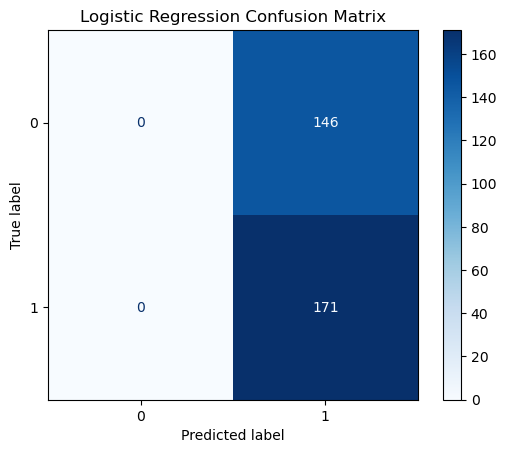

In [139]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Confusion Matrix

The confusion matrix provides a detailed evaluation of the Logistic Regression model by comparing predicted outcomes with the actual observations.

The results indicate that the model classified nearly all observations as an upward price movement (Class 1). While this produced an overall accuracy of 53.94%, the model was unable to correctly identify days when the stock price declined.

This suggests that the current feature set provides limited predictive power for distinguishing between upward and downward daily price movements. Future improvements may include additional technical indicators, feature engineering, class balancing techniques, or alternative machine learning algorithms to improve classification performance.

---

# Random Forest Feature Importance

In [143]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Daily Return,0.222071
3,Volatility,0.200355
4,RSI,0.197885
1,MA20,0.191958
2,MA50,0.187731


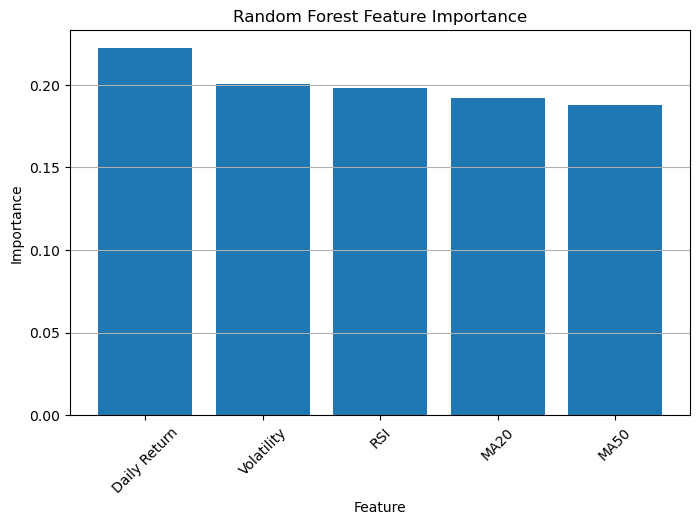

In [145]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Feature")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

## Random Forest Feature Importance

Feature importance measures the relative contribution of each technical indicator to the Random Forest model's predictions.

The results identify which variables had the greatest influence when predicting NVIDIA's next-day price direction. This information improves the interpretability of the model by highlighting the indicators that contain the most predictive value.

Although the Random Forest model achieved lower overall accuracy than Logistic Regression, feature importance remains valuable for understanding how the model utilized the available financial indicators.

In [155]:
html = f"""
<!DOCTYPE html>
<html>
<head>
    <title>AI Investment Decision Engine Version 3</title>
</head>
<body>

    <h1>AI Investment Decision Engine - Version 3</h1>

    <h2>Author</h2>
    <p>Alex Alvarez</p>

    <h2>Project Summary</h2>
    <p>
    This project analyzes NVIDIA (NVDA) historical stock data using Python,
    technical indicators, and machine learning models to predict next-day
    stock price direction.
    </p>

    <h2>Model Results</h2>
    <table border="1">
        <tr>
            <th>Model</th>
            <th>Accuracy</th>
        </tr>
        <tr>
            <td>Logistic Regression</td>
            <td>53.94%</td>
        </tr>
        <tr>
            <td>XGBoost</td>
            <td>51.10%</td>
        </tr>
        <tr>
            <td>Random Forest</td>
            <td>48.26%</td>
        </tr>
    </table>

    <h2>Conclusion</h2>
    <p>
    Logistic Regression achieved the highest overall accuracy, but the
    confusion matrix showed that the model primarily predicted upward price
    movement. This indicates limitations in the current feature set and
    creates an opportunity for future model improvement.
    </p>

</body>
</html>
"""

with open("AI_Investment_Decision_Engine_Version_3_Report.html", "w", encoding="utf-8") as file:
    file.write(html)

print("HTML report created.")

HTML report created.


---

# Final Conclusion

This Version 3 project improved the AI Investment Decision Engine by adding technical indicators, machine learning model comparison, confusion matrix analysis, and feature importance.

The results show that Logistic Regression achieved the highest overall accuracy at 53.94%, followed by XGBoost at 51.10% and Random Forest at 48.26%. However, the confusion matrix showed that the Logistic Regression model primarily predicted upward price movement, indicating limitations in the current feature set.

Overall, this project demonstrates a complete financial machine learning workflow using Python, including data collection, feature engineering, visualization, model training, evaluation, and interpretation.

Future improvements should include additional indicators, feature scaling, class balancing, and stronger predictive features.